<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/saft_vr_mie_association_from_fundamental_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From molecular hydrogen bonds to SAFT-VR Mie association and NeqSim

This executable companion to [From fundamental interactions to SAFT-VR Mie parameters and NeqSim](saft_vr_mie_from_fundamental_models.ipynb) adds **associating components**.

Water is the worked 4C example:

1. **PySCF** calculates counterpoise-corrected water-dimer radial and angular interactions.
2. Molecular geometry supplies two donor and two acceptor sites.
3. A transparent bonding-region map estimates the association energy
   $\epsilon^{HB}$ and the NeqSim SAFT-VR Mie kernel volume $K^{HB}$.
4. **teqp** reproduces a published Dufal water site-fraction benchmark.
5. **NeqSim** receives the mapped parameters, solves the association
   mass action, and propagates them to a heater duty.

The live quantum route is a **teaching-quality bottom-up estimate**.
Production parameters require a larger electronic-structure protocol,
an explicit coarse-graining definition, condensed-phase validation, and
mixture cross-association work.


## 1. What association adds to the non-associating workflow

| Parameter or choice | Fundamental information used here | What one dimer minimum cannot determine |
|---|---|---|
| Site topology | Lewis structure and molecular geometry | Liquid-state site blocking and cooperativity |
| $\epsilon^{HB}$ | Counterpoise-corrected dimer well | Many-body, zero-point, thermal, and solvent corrections |
| $K^{HB}$ | Radial shell and donor/acceptor angular cones | Unique value without a stated bonding criterion |
| Cross association | Unlike dimer surfaces or combining rule | Solvation and mixture parameters |
| Nonpolar $m,\sigma,\epsilon,\lambda_r,\lambda_a$ | Companion isotropic-potential workflow | Chain coarse graining |

The notebook therefore keeps three routes separate:

- a live molecular-to-NeqSim teaching map;
- the packaged NeqSim water parameters;
- an independent published Dufal/teqp benchmark.

Raw association volumes are implementation-kernel parameters and should
not be copied between formulations merely because their units match.


## 2. Open-source stack and clean Colab setup

| Layer | Open-source software | Role |
|---|---|---|
| Electronic structure | [PySCF](https://pyscf.org/) | MP2 surface and CCSD(T) calibration |
| Mapping | NumPy and SciPy | Interpolation, geometry, and sensitivity |
| Independent association EOS | [teqp](https://teqp.readthedocs.io/en/latest/models/Association.html) | Published Dufal water benchmark |
| Engineering thermodynamics | [NeqSim](https://github.com/equinor/neqsim) | Association, phase behavior, properties, and process equipment |

Exact specialist versions make the executed result reproducible. A clean
Colab runtime needs no repository checkout or local JAR.


In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys


required = {
    "neqsim": "3.16.0",
    "teqp": "0.23.2",
    "pyscf": "2.14.0",
}

install_specs = []
for package, version in required.items():
    installed = (
        importlib.metadata.version(package)
        if importlib.util.find_spec(package) is not None
        else None
    )
    if installed != version:
        install_specs.append(f"{package}=={version}")

if install_specs:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-cache-dir",
            "--disable-pip-version-check",
            *install_specs,
        ]
    )

print("Specialist packages are ready:", required)


Specialist packages are ready: {'neqsim': '3.16.0', 'teqp': '0.23.2', 'pyscf': '2.14.0'}


## 3. Imports, constants, and runtime provenance

Electronic interaction energies are reported as $u/k_B$ in kelvin.
Multiplication by the molar gas constant converts this convention to
joules per mole.


In [2]:
import importlib.metadata
import json
import math
import os
import platform
import subprocess
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import teqp
from IPython.display import display
from pyscf import cc, gto, lib, mp, scf

from neqsim import jneqsim


R = 8.31446261815324  # J mol^-1 K^-1
N_A = 6.02214076e23  # mol^-1
HARTREE_TO_K = 315775.02480407
ANGSTROM3_TO_M3 = 1.0e-30
WATER_MOLAR_MASS = 0.01801528  # kg mol^-1

# Some sandboxed validators hide /proc/<pid>/statm. Colab does not.
if not os.path.exists(f"/proc/{os.getpid()}/statm"):
    lib.current_memory = lambda: (0.0, 0.0)
lib.num_threads(min(2, os.cpu_count() or 1))

runtime = {
    "python": platform.python_version(),
    "java": subprocess.run(
        ["java", "-version"],
        check=True,
        capture_output=True,
        text=True,
    ).stderr.splitlines()[0],
    **{
        package: importlib.metadata.version(package)
        for package in required
    },
}
display(pd.Series(runtime, name="version"))


python                                 3.12.13
java      openjdk version "17.0.19" 2026-04-21
neqsim                                  3.16.0
teqp                                    0.23.2
pyscf                                   2.14.0
Name: version, dtype: str

## 4. SAFT association equations and the mapping target

For site $A$ on component $i$, Wertheim TPT1 gives the non-bonded site
fraction

$$
X_{iA}=\left[
1+\rho\sum_j x_j\sum_B X_{jB}\Delta_{iA,jB}
\right]^{-1}.
$$

In NeqSim's SAFT-VR Mie association implementation, the compatible-site
strength has the form

$$
\Delta^{HB}=N_A K^{HB} I(T,\rho^*)
\left[\exp\left(\frac{\epsilon^{HB}}{RT}\right)-1\right].
$$

Here $I$ is the Dufal reference-fluid integral. For a pure symmetric 4C
water model, each donor sees two acceptors and

$$
2\rho\Delta^{HB}X^2+X-1=0.
$$

The association Helmholtz contribution is

$$
\frac{A^{assoc}}{Nk_BT}
=\sum_A\left(\ln X_A-\frac{X_A}{2}+\frac{1}{2}\right).
$$

The live map first estimates a molecular bonding volume $V_{bond}$.
It then matches the dilute-limit strength of that bonding region to the
NeqSim kernel:

$$
K^{HB}_{NeqSim}=\frac{V_{bond}}{I(T_{ref},\rho^*\rightarrow0)}.
$$


## 5. Water geometry and the 4C site scheme

Water has two hydrogen donor directions and two lone-pair acceptor
directions. The 4C scheme allows donor-acceptor bonds but excludes
donor-donor and acceptor-acceptor bonds. The fixed monomer geometry below
uses $r_{OH}=0.9572$ Å and $\angle HOH=104.52^\circ$.


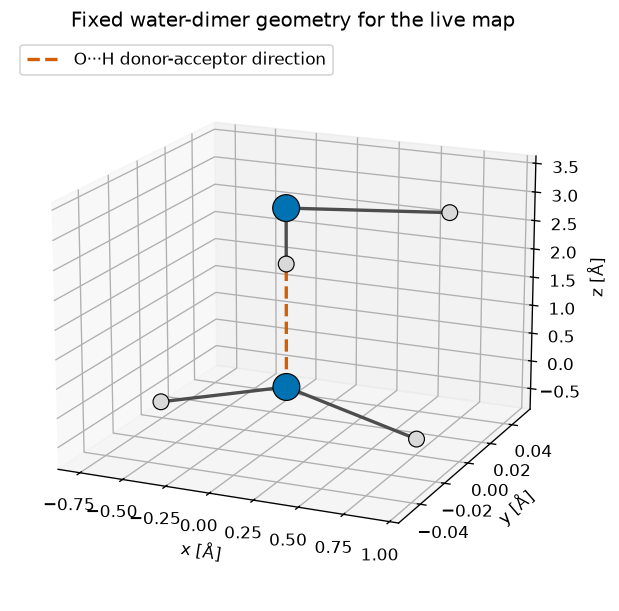

In [3]:
def water_dimer_atoms(distance_angstrom, donor_tilt_deg=0.0):
    r_oh = 0.9572
    angle = math.radians(104.52)
    half_angle = angle / 2.0

    acceptor = [
        ("O", (0.0, 0.0, 0.0)),
        (
            "H",
            (
                r_oh * math.sin(half_angle),
                0.0,
                -r_oh * math.cos(half_angle),
            ),
        ),
        (
            "H",
            (
                -r_oh * math.sin(half_angle),
                0.0,
                -r_oh * math.cos(half_angle),
            ),
        ),
    ]

    donor_relative = [
        ("O", (0.0, 0.0, 0.0)),
        ("H", (0.0, 0.0, -r_oh)),
        (
            "H",
            (
                r_oh * math.sin(angle),
                0.0,
                -r_oh * math.cos(angle),
            ),
        ),
    ]
    tilt = math.radians(donor_tilt_deg)
    donor = []
    for symbol, (x_value, y_value, z_value) in donor_relative:
        x_rotated = (
            x_value * math.cos(tilt)
            + z_value * math.sin(tilt)
        )
        z_rotated = (
            -x_value * math.sin(tilt)
            + z_value * math.cos(tilt)
        )
        donor.append(
            (
                symbol,
                (
                    x_rotated,
                    y_value,
                    z_rotated + distance_angstrom,
                ),
            )
        )
    return acceptor + donor


geometry_atoms = water_dimer_atoms(3.10)
coordinates = np.array([xyz for _, xyz in geometry_atoms])
atom_colors = [
    "#0072B2" if symbol == "O" else "#D9D9D9"
    for symbol, _ in geometry_atoms
]
atom_sizes = [
    260 if symbol == "O" else 90
    for symbol, _ in geometry_atoms
]

fig = plt.figure(figsize=(7.2, 5.2))
axis = fig.add_subplot(111, projection="3d")
axis.scatter(
    coordinates[:, 0],
    coordinates[:, 1],
    coordinates[:, 2],
    c=atom_colors,
    s=atom_sizes,
    edgecolor="black",
    linewidth=0.7,
    depthshade=False,
)
for oxygen, hydrogen in [(0, 1), (0, 2), (3, 4), (3, 5)]:
    segment = coordinates[[oxygen, hydrogen]]
    axis.plot(
        segment[:, 0],
        segment[:, 1],
        segment[:, 2],
        color="#4D4D4D",
        linewidth=2.0,
    )
axis.plot(
    coordinates[[0, 4], 0],
    coordinates[[0, 4], 1],
    coordinates[[0, 4], 2],
    color="#D55E00",
    linestyle="--",
    linewidth=2.0,
    label="O···H donor-acceptor direction",
)
axis.set(
    xlabel="x [Å]",
    ylabel="y [Å]",
    zlabel="z [Å]",
    title="Fixed water-dimer geometry for the live map",
)
axis.legend(loc="upper left")
axis.view_init(elev=17, azim=-66)
plt.tight_layout()
plt.show()


## 6. Counterpoise-corrected interaction calculations

The Boys-Bernardi interaction energy is

$$
E_{int}^{CP}=E_{AB}^{AB}-E_A^{AB}-E_B^{AB},
$$

where the monomer calculations retain the partner's basis as ghost
functions. Density-fitted frozen-core MP2 makes a radial/angular scan
fast. One counterpoise-corrected CCSD(T) point calibrates its well depth.

This fixed-geometry aug-cc-pVDZ protocol omits basis-set extrapolation,
monomer relaxation, zero-point energy, thermal averaging, polarization
by the liquid, and many-body hydrogen-bond cooperativity.


In [4]:
def atom_block(atoms, real_indices):
    rows = []
    for index, (symbol, xyz) in enumerate(atoms):
        label = (
            symbol
            if index in real_indices
            else f"ghost-{symbol}"
        )
        rows.append(
            f"{label} {xyz[0]} {xyz[1]} {xyz[2]}"
        )
    return "; ".join(rows)


def correlated_energy(atoms, real_indices, method):
    molecule = gto.M(
        atom=atom_block(atoms, real_indices),
        basis="aug-cc-pvdz",
        unit="Angstrom",
        verbose=0,
    )
    mean_field = scf.RHF(molecule).density_fit()
    mean_field.conv_tol = 1.0e-10
    mean_field.kernel()

    frozen_orbitals = sum(
        1
        for index in real_indices
        if atoms[index][0] == "O"
    )
    if method == "MP2":
        solver = mp.MP2(
            mean_field,
            frozen=frozen_orbitals,
        ).density_fit()
        solver.kernel()
        return mean_field.e_tot + solver.e_corr

    if method == "CCSD(T)":
        solver = cc.CCSD(
            mean_field,
            frozen=frozen_orbitals,
        )
        solver.conv_tol = 1.0e-8
        solver.kernel()
        return (
            mean_field.e_tot
            + solver.e_corr
            + solver.ccsd_t()
        )

    raise ValueError(f"Unknown method: {method}")


def cp_interaction_k(
    distance_angstrom,
    donor_tilt_deg=0.0,
    method="MP2",
):
    atoms = water_dimer_atoms(
        distance_angstrom,
        donor_tilt_deg,
    )
    energy = correlated_energy(
        atoms,
        set(range(6)),
        method,
    )
    energy -= correlated_energy(
        atoms,
        {0, 1, 2},
        method,
    )
    energy -= correlated_energy(
        atoms,
        {3, 4, 5},
        method,
    )
    return energy * HARTREE_TO_K


## 7. Live radial and directional interaction surface

The radial scan follows one O-H···O direction. The tilt scan rotates the
selected donor away from that direction. Angles above the local site
basin are deliberately excluded from the mapping because the second
equivalent O-H donor becomes the nearest donor direction.


In [5]:
quantum_start = time.time()
radial_distances = np.array(
    [
        2.45,
        2.60,
        2.75,
        2.85,
        2.95,
        3.10,
        3.35,
        3.70,
        4.20,
    ]
)
radial_mp2_k = np.array(
    [
        cp_interaction_k(distance)
        for distance in radial_distances
    ]
)
minimum_index = int(np.argmin(radial_mp2_k))
minimum_distance = radial_distances[minimum_index]

tilt_angles = np.array(
    [0.0, 10.0, 20.0, 30.0, 45.0, 60.0]
)
angular_mp2_k = np.array(
    [
        cp_interaction_k(minimum_distance, angle)
        for angle in tilt_angles
    ]
)
quantum_scan_seconds = time.time() - quantum_start

scan_table = pd.DataFrame(
    {
        "O-O distance [Å]": radial_distances,
        "MP2 CP interaction [K]": radial_mp2_k,
    }
)
display(scan_table.round(3))
print(
    "MP2 radial and angular scans completed in "
    f"{quantum_scan_seconds:.1f} s"
)


MP2 radial and angular scans completed in 29.9 s


,O-O distance [Å],MP2 CP interaction [K]
0,2.45,1926.606
1,2.60,-325.365
2,2.75,-1376.770
3,2.85,-1696.914
4,2.95,-1835.741
5,3.10,-1843.278
6,3.35,-1614.819
7,3.70,-1202.950
8,4.20,-762.349


In [6]:
calibration_start = time.time()
calibration_ccsdt_k = cp_interaction_k(
    minimum_distance,
    method="CCSD(T)",
)
calibration_seconds = time.time() - calibration_start
calibration_scale = (
    calibration_ccsdt_k
    / radial_mp2_k[minimum_index]
)
radial_calibrated_k = radial_mp2_k * calibration_scale
angular_calibrated_k = angular_mp2_k * calibration_scale

calibration_table = pd.Series(
    {
        "O-O distance [Å]": minimum_distance,
        "MP2 interaction [K]": radial_mp2_k[
            minimum_index
        ],
        "CCSD(T) interaction [K]": calibration_ccsdt_k,
        "CCSD(T)/MP2 scale [-]": calibration_scale,
        "CCSD(T) wall time [s]": calibration_seconds,
    },
    name="Counterpoise calibration",
)
display(calibration_table.round(5))


O-O distance [Å]              3.10000
MP2 interaction [K]       -1843.27799
CCSD(T) interaction [K]   -1837.11757
CCSD(T)/MP2 scale [-]         0.99666
CCSD(T) wall time [s]        71.64661
Name: Counterpoise calibration, dtype: float64

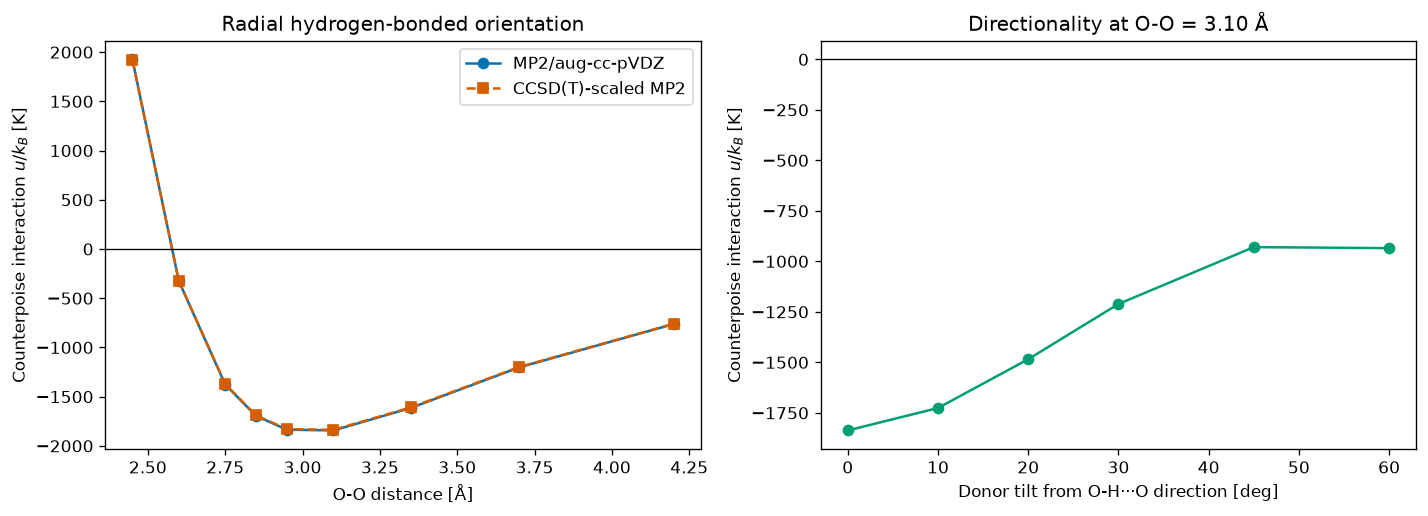

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
axes[0].plot(
    radial_distances,
    radial_mp2_k,
    "o-",
    color="#0072B2",
    label="MP2/aug-cc-pVDZ",
)
axes[0].plot(
    radial_distances,
    radial_calibrated_k,
    "s--",
    color="#D55E00",
    label="CCSD(T)-scaled MP2",
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set(
    xlabel="O-O distance [Å]",
    ylabel="Counterpoise interaction $u/k_B$ [K]",
    title="Radial hydrogen-bonded orientation",
)
axes[0].legend()

axes[1].plot(
    tilt_angles,
    angular_calibrated_k,
    "o-",
    color="#009E73",
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set(
    xlabel="Donor tilt from O-H···O direction [deg]",
    ylabel="Counterpoise interaction $u/k_B$ [K]",
    title=f"Directionality at O-O = {minimum_distance:.2f} Å",
)
plt.tight_layout()
plt.show()


## 8. Map the molecular surface to $\epsilon^{HB}$ and $V_{bond}$

The association energy is the calibrated dimer well depth. The bonding
region is defined transparently as configurations retaining at least 60%
of that depth. Linear interpolation gives a radial shell
$[r_{low},r_{high}]$ and a donor cone half-angle $\theta_c$.

Assuming the same cone for an acceptor site, the geometric volume for
one compatible donor-acceptor site pair is

$$
V_{bond}=\frac{4\pi}{3}
\left(r_{high}^3-r_{low}^3\right)
\left[\frac{1-\cos\theta_c}{2}\right]^2.
$$

The 60% criterion is a coarse-graining definition, not a universal
constant. Its sensitivity is evaluated below.


In [8]:
def first_crossing(x_values, y_values, target):
    for index in range(len(x_values) - 1):
        y_left = y_values[index] - target
        y_right = y_values[index + 1] - target
        if y_left == 0.0:
            return float(x_values[index])
        if y_left * y_right <= 0.0:
            fraction = -y_left / (y_right - y_left)
            return float(
                x_values[index]
                + fraction
                * (x_values[index + 1] - x_values[index])
            )
    raise ValueError("The sampled range does not bracket a crossing")


def bonding_geometry(depth_fraction):
    well_depth_k = -float(np.min(radial_calibrated_k))
    threshold_k = -depth_fraction * well_depth_k
    minimum = int(np.argmin(radial_calibrated_k))

    r_low = first_crossing(
        radial_distances[: minimum + 1],
        radial_calibrated_k[: minimum + 1],
        threshold_k,
    )
    r_high = first_crossing(
        radial_distances[minimum:],
        radial_calibrated_k[minimum:],
        threshold_k,
    )
    theta_cutoff = first_crossing(
        tilt_angles,
        angular_calibrated_k,
        threshold_k,
    )
    shell_angstrom3 = (
        4.0
        * math.pi
        / 3.0
        * (r_high**3 - r_low**3)
    )
    one_cone_fraction = (
        1.0 - math.cos(math.radians(theta_cutoff))
    ) / 2.0
    bonding_volume_angstrom3 = (
        shell_angstrom3 * one_cone_fraction**2
    )
    return {
        "depth_fraction": depth_fraction,
        "threshold_k": threshold_k,
        "r_low_angstrom": r_low,
        "r_high_angstrom": r_high,
        "theta_cutoff_deg": theta_cutoff,
        "shell_angstrom3": shell_angstrom3,
        "orientation_fraction": one_cone_fraction**2,
        "bonding_volume_angstrom3": (
            bonding_volume_angstrom3
        ),
    }


mapping_geometry = bonding_geometry(0.60)
mapped_epsilon_jmol = (
    -float(np.min(radial_calibrated_k)) * R
)
display(
    pd.Series(
        mapping_geometry
        | {
            "epsilon_HB [J/mol]": mapped_epsilon_jmol,
        },
        name="Live molecular bonding map",
    ).round(6)
)


depth_fraction                  0.600000
threshold_k                 -1102.270543
r_low_angstrom                  2.711366
r_high_angstrom                 3.810058
theta_cutoff_deg               35.800082
shell_angstrom3               148.183776
orientation_fraction            0.008924
bonding_volume_angstrom3        1.322436
epsilon_HB [J/mol]          15274.645370
Name: Live molecular bonding map, dtype: float64

## 9. Read the NeqSim kernel and packaged water parameters

NeqSim 3.16.0 stores SAFT-VR Mie-specific association parameters
separately from the generic SAFT fields. Association schemes are
initialized during `system.init(0)`, so that call is mandatory after
an override and before the flash.

The dilute reference-fluid integral $I_0$ is evaluated with NeqSim
itself. Dividing the molecular bonding volume by $I_0$ maps it to the
normalization used by NeqSim's Dufal association kernel.


In [9]:
def override_water_association(
    system,
    epsilon_hb_jmol,
    k_hb_m3,
):
    for phase_index in range(
        int(system.getMaxNumberOfPhases())
    ):
        component = (
            system.getPhase(phase_index)
            .getComponent("water")
        )
        component.setAssociationEnergySAFTVRMie(
            epsilon_hb_jmol
        )
        component.setAssociationVolumeSAFTVRMie(k_hb_m3)
    system.init(0)


def build_neqsim_water(
    temperature_k,
    pressure_bar,
    epsilon_hb_jmol=None,
    k_hb_m3=None,
):
    system = jneqsim.thermo.system.SystemSAFTVRMie(
        temperature_k,
        pressure_bar,
    )
    system.addComponent("water", 1.0)
    if epsilon_hb_jmol is not None:
        override_water_association(
            system,
            epsilon_hb_jmol,
            k_hb_m3,
        )
    else:
        system.init(0)
    operations = (
        jneqsim.thermodynamicoperations
        .ThermodynamicOperations(system)
    )
    operations.TPflash()
    system.initProperties()
    return system


packaged_probe = build_neqsim_water(300.0, 1.0)
packaged_component = (
    packaged_probe.getPhase(0).getComponent("water")
)
packaged_epsilon_jmol = float(
    packaged_component.getAssociationEnergySAFTVRMie()
)
packaged_k_m3 = float(
    packaged_component.getAssociationVolumeSAFTVRMie()
)

dilute_probe = build_neqsim_water(298.15, 1.0e-6)
dilute_integral = float(
    dilute_probe.getPhase(0).getGcpaAssoc()
)
mapped_k_m3 = (
    mapping_geometry["bonding_volume_angstrom3"]
    * ANGSTROM3_TO_M3
    / dilute_integral
)

packaged_audit = pd.Series(
    {
        "association scheme": str(
            packaged_component.getAssociationScheme()
        ),
        "number of sites": int(
            packaged_component
            .getNumberOfAssociationSites()
        ),
        "epsilon_HB [J/mol]": packaged_epsilon_jmol,
        "K_HB [m3]": f"{packaged_k_m3:.6e}",
        "K_HB [Å3]": (
            packaged_k_m3 / ANGSTROM3_TO_M3
        ),
        "dilute Dufal integral I0 [-]": dilute_integral,
    },
    name="NeqSim 3.16.0 packaged water",
)
display(packaged_audit)


association scheme                        4C
number of sites                            4
epsilon_HB [J/mol]                16506.6756
K_HB [m3]                       1.016900e-28
K_HB [Å3]                             101.69
dilute Dufal integral I0 [-]        0.022265
Name: NeqSim 3.16.0 packaged water, dtype: object

In [10]:
parameter_routes = pd.DataFrame(
    [
        {
            "Route": "Live molecular map -> NeqSim kernel",
            "Scheme": "4C",
            "epsilon_HB [J/mol]": mapped_epsilon_jmol,
            "Kernel volume [Å3]": (
                mapped_k_m3 / ANGSTROM3_TO_M3
            ),
            "Kernel": "NeqSim Dufal I",
        },
        {
            "Route": "NeqSim 3.16.0 packaged water",
            "Scheme": "4C",
            "epsilon_HB [J/mol]": packaged_epsilon_jmol,
            "Kernel volume [Å3]": (
                packaged_k_m3 / ANGSTROM3_TO_M3
            ),
            "Kernel": "NeqSim Dufal I",
        },
        {
            "Route": "Dufal 2015 water in teqp",
            "Scheme": "4C",
            "epsilon_HB [J/mol]": 13303.140189045183,
            "Kernel volume [Å3]": 0.49666,
            "Kernel": "teqp Dufal",
        },
    ]
)
display(parameter_routes.round(5))
print(
    "Do not compare or copy the raw teqp and NeqSim volumes "
    "without matching their association-kernel definitions."
)


Do not compare or copy the raw teqp and NeqSim volumes without matching their association-kernel definitions.


,Route,Scheme,epsilon_HB [J/mol],Kernel volume [Å3],Kernel
0,Live molecular map -> NeqSim kernel,4C,15274.64537,59.39445,NeqSim Dufal I
1,NeqSim 3.16.0 packaged water,4C,16506.67560,101.69000,NeqSim Dufal I
2,Dufal 2015 water in teqp,4C,13303.14019,0.49666,teqp Dufal


## 10. Coarse-graining sensitivity of the association volume

The cutoff is varied from 55% to 75% of the calibrated well depth.
This is a **definition sensitivity**, not a statistical confidence
interval. It usually dominates the small MP2-to-CCSD(T) energy
correction and shows why the bonding convention must accompany any
reported $K^{HB}$.


,depth_fraction,r_low_angstrom,r_high_angstrom,theta_cutoff_deg,bonding_volume_angstrom3,neqsim_k_angstrom3
0,0.550,2.69822,3.91465,40.69372,2.47013,110.94054
1,0.575,2.70479,3.86235,38.24690,1.82525,81.97718
2,0.600,2.71137,3.81006,35.80008,1.32244,59.39445
3,0.625,2.71794,3.75776,33.35326,0.93701,42.08394
4,0.650,2.72451,3.70547,30.90644,0.64721,29.06826
5,0.675,2.73109,3.66494,28.94217,0.47133,21.16886
6,0.700,2.73766,3.62578,27.26186,0.35076,15.75351
7,0.725,2.74424,3.58662,25.58155,0.25632,11.51205
8,0.750,2.75178,3.54746,23.90124,0.18333,8.23371


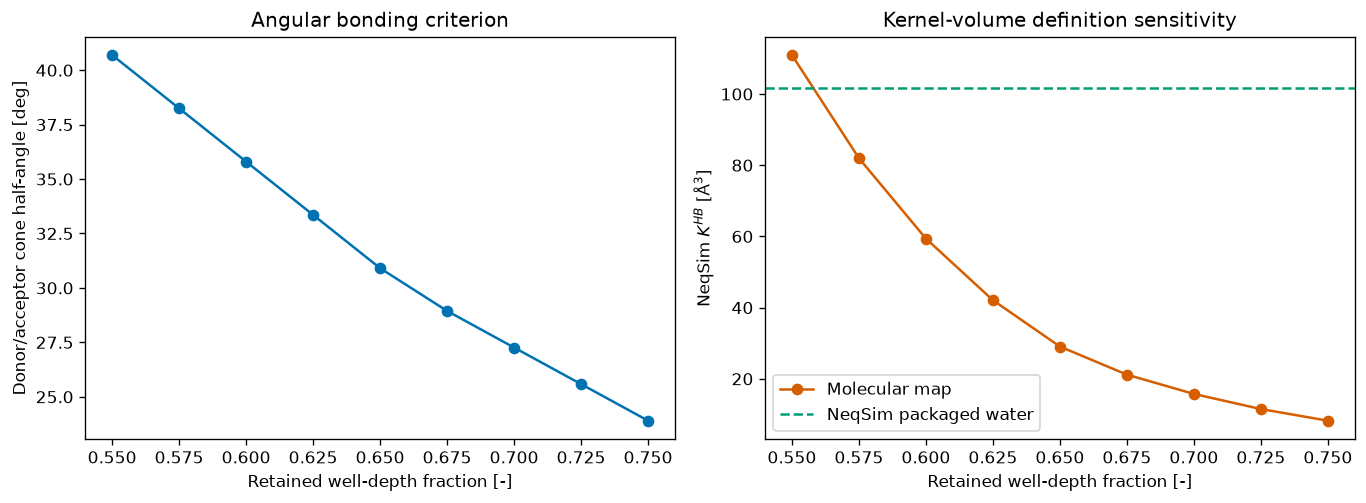

In [11]:
cutoff_fractions = np.linspace(0.55, 0.75, 9)
cutoff_rows = []
for fraction in cutoff_fractions:
    geometry = bonding_geometry(float(fraction))
    cutoff_rows.append(
        geometry
        | {
            "neqsim_k_angstrom3": (
                geometry["bonding_volume_angstrom3"]
                / dilute_integral
            )
        }
    )
cutoff_table = pd.DataFrame(cutoff_rows)
display(
    cutoff_table[
        [
            "depth_fraction",
            "r_low_angstrom",
            "r_high_angstrom",
            "theta_cutoff_deg",
            "bonding_volume_angstrom3",
            "neqsim_k_angstrom3",
        ]
    ].round(5)
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].plot(
    cutoff_table["depth_fraction"],
    cutoff_table["theta_cutoff_deg"],
    "o-",
    color="#0072B2",
)
axes[0].set(
    xlabel="Retained well-depth fraction [-]",
    ylabel="Donor/acceptor cone half-angle [deg]",
    title="Angular bonding criterion",
)

axes[1].plot(
    cutoff_table["depth_fraction"],
    cutoff_table["neqsim_k_angstrom3"],
    "o-",
    color="#D55E00",
    label="Molecular map",
)
axes[1].axhline(
    packaged_k_m3 / ANGSTROM3_TO_M3,
    color="#009E73",
    linestyle="--",
    label="NeqSim packaged water",
)
axes[1].set(
    xlabel="Retained well-depth fraction [-]",
    ylabel="NeqSim $K^{HB}$ [Å$^3$]",
    title="Kernel-volume definition sensitivity",
)
axes[1].legend()
plt.tight_layout()
plt.show()


## 11. Independent published Dufal benchmark with teqp

This test does not validate NeqSim by copying a NeqSim result. It builds
the published Dufal SAFT-VR Mie water parameter set in teqp and reproduces
the non-bonded site fraction reported in teqp's Dufal-water verification
example: $X_A=0.08922902098124982$ at 290 K and the specified molar
density.

The Dufal parameter set differs from NeqSim's packaged water set, so this
is a theory/reference benchmark rather than a same-parameter
cross-implementation equality claim.


In [12]:
dufal_water = {
    "nonpolar": {
        "kind": "SAFT-VR-Mie",
        "model": {
            "coeffs": [
                {
                    "name": "Water",
                    "BibTeXKey": "Dufal-2015",
                    "m": 1.0,
                    "sigma_Angstrom": 3.0555,
                    "epsilon_over_k": 418.0,
                    "lambda_r": 35.823,
                    "lambda_a": 6.0,
                }
            ]
        },
    },
    "association": {
        "kind": "Dufal",
        "model": {
            "sigma / m": [3.0555e-10],
            "epsilon / J/mol": [3475.445374388054],
            "lambda_r": [35.823],
            "epsilon_HB / J/mol": [
                13303.140189045183
            ],
            "K_HB / m^3": [496.66e-30],
            "kmat": [[0.0]],
            "Delta_rule": "Dufal",
            "molecule_sites": [["e", "e", "H", "H"]],
        },
    },
}
teqp_model = teqp.make_model(
    {
        "kind": "genericSAFT",
        "model": dufal_water,
    }
)
benchmark_temperature = 290.0
benchmark_density = (
    1.011 * 100.0**3 / 1000.0 / 0.018015
)
benchmark_calcs = teqp_model.get_assoc_calcs(
    benchmark_temperature,
    benchmark_density,
    np.array([1.0]),
)
benchmark_x = float(benchmark_calcs["X_A"][0])
expected_benchmark_x = 0.08922902098124982

benchmark_table = pd.Series(
    {
        "temperature [K]": benchmark_temperature,
        "molar density [mol/m3]": benchmark_density,
        "teqp X_A [-]": benchmark_x,
        "published/example X_A [-]": expected_benchmark_x,
        "absolute difference [-]": abs(
            benchmark_x - expected_benchmark_x
        ),
    },
    name="Independent Dufal site-fraction benchmark",
)
display(benchmark_table)


temperature [K]                290.000000
molar density [mol/m3]       56119.900083
teqp X_A [-]                     0.089229
published/example X_A [-]        0.089229
absolute difference [-]          0.000000
Name: Independent Dufal site-fraction benchmark, dtype: float64

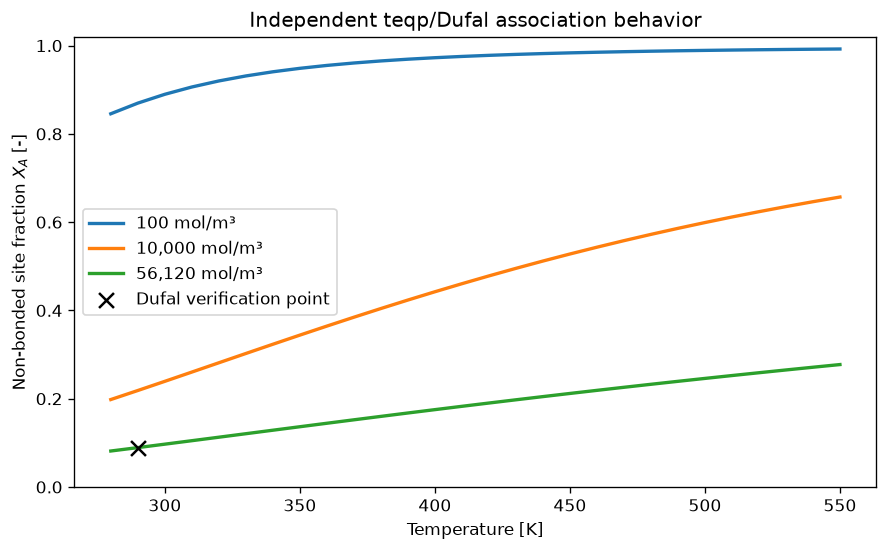

In [13]:
teqp_temperatures = np.linspace(280.0, 550.0, 28)
teqp_densities = [100.0, 10000.0, benchmark_density]
teqp_density_labels = [
    "100 mol/m³",
    "10,000 mol/m³",
    f"{benchmark_density:,.0f} mol/m³",
]

fig, axis = plt.subplots(figsize=(7.5, 4.7))
for density, label in zip(
    teqp_densities,
    teqp_density_labels,
):
    x_values = [
        float(
            teqp_model.get_assoc_calcs(
                temperature,
                density,
                np.array([1.0]),
            )["X_A"][0]
        )
        for temperature in teqp_temperatures
    ]
    axis.plot(
        teqp_temperatures,
        x_values,
        linewidth=2.0,
        label=label,
    )
axis.scatter(
    [benchmark_temperature],
    [expected_benchmark_x],
    color="black",
    marker="x",
    s=80,
    label="Dufal verification point",
    zorder=5,
)
axis.set(
    xlabel="Temperature [K]",
    ylabel="Non-bonded site fraction $X_A$ [-]",
    title="Independent teqp/Dufal association behavior",
    ylim=(0.0, 1.02),
)
axis.legend()
plt.tight_layout()
plt.show()


## 12. Inject mapped association parameters into NeqSim

Three parameter routes are compared:

- **mapped:** live quantum/geometric teaching map;
- **packaged:** NeqSim 3.16.0 water defaults;
- **association off:** same nonpolar water parameters with zero
  association strength.

Turning association off is a diagnostic, not a viable water model.
The dramatic phase and density changes show what the association term is
carrying.


In [14]:
parameter_sets = {
    "Mapped molecular": (
        mapped_epsilon_jmol,
        mapped_k_m3,
    ),
    "NeqSim packaged": (
        packaged_epsilon_jmol,
        packaged_k_m3,
    ),
    "Association off": (0.0, 0.0),
}
state_points = [
    (300.0, 1.0),
    (400.0, 1.0),
    (450.0, 10.0),
    (550.0, 50.0),
]

state_rows = []
state_systems = {}
for temperature_k, pressure_bar in state_points:
    for label, (
        epsilon_hb_jmol,
        k_hb_m3,
    ) in parameter_sets.items():
        system = build_neqsim_water(
            temperature_k,
            pressure_bar,
            epsilon_hb_jmol,
            k_hb_m3,
        )
        state_systems[
            (temperature_k, pressure_bar, label)
        ] = system
        phase = system.getPhase(0)
        component = phase.getComponent("water")
        x_sites = [
            float(value)
            for value in component.getXsiteAssoc()
        ]
        state_rows.append(
            {
                "T [K]": temperature_k,
                "P [bar]": pressure_bar,
                "Parameter set": label,
                "Phase": str(
                    phase.getPhaseTypeName()
                ),
                "Density [kg/m3]": float(
                    phase.getDensity("kg/m3")
                ),
                "Z [-]": float(phase.getZ()),
                "Mean X_A [-]": (
                    float(np.mean(x_sites))
                    if x_sites
                    else 1.0
                ),
                "F_assoc [-]": float(
                    phase.F_ASSOC_SAFT()
                ),
            }
        )
state_table = pd.DataFrame(state_rows)
display(state_table.round(6))


,T [K],P [bar],Parameter set,Phase,Density [kg/m3],Z [-],Mean X_A [-],F_assoc [-]
0,300.0,1.0,Mapped molecular,aqueous,990.584374,0.000729,0.116991,-6.816621
1,300.0,1.0,NeqSim packaged,aqueous,999.906012,0.000722,0.070732,-8.736866
2,300.0,1.0,Association off,gas,0.723612,0.998097,1.000000,0.000000
3,400.0,1.0,Mapped molecular,gas,0.546848,0.990544,0.995656,-0.008726
4,400.0,1.0,NeqSim packaged,gas,0.554086,0.977604,0.989192,-0.021851
5,400.0,1.0,Association off,gas,0.542089,0.999240,1.000000,0.000000
6,450.0,10.0,Mapped molecular,aqueous,830.501148,0.005798,0.328750,-3.107331
7,450.0,10.0,NeqSim packaged,aqueous,884.293330,0.005445,0.214430,-4.587950
8,450.0,10.0,Association off,gas,4.838645,0.995093,1.000000,0.000000
9,550.0,50.0,Mapped molecular,gas,21.865952,0.900822,0.955561,-0.092948


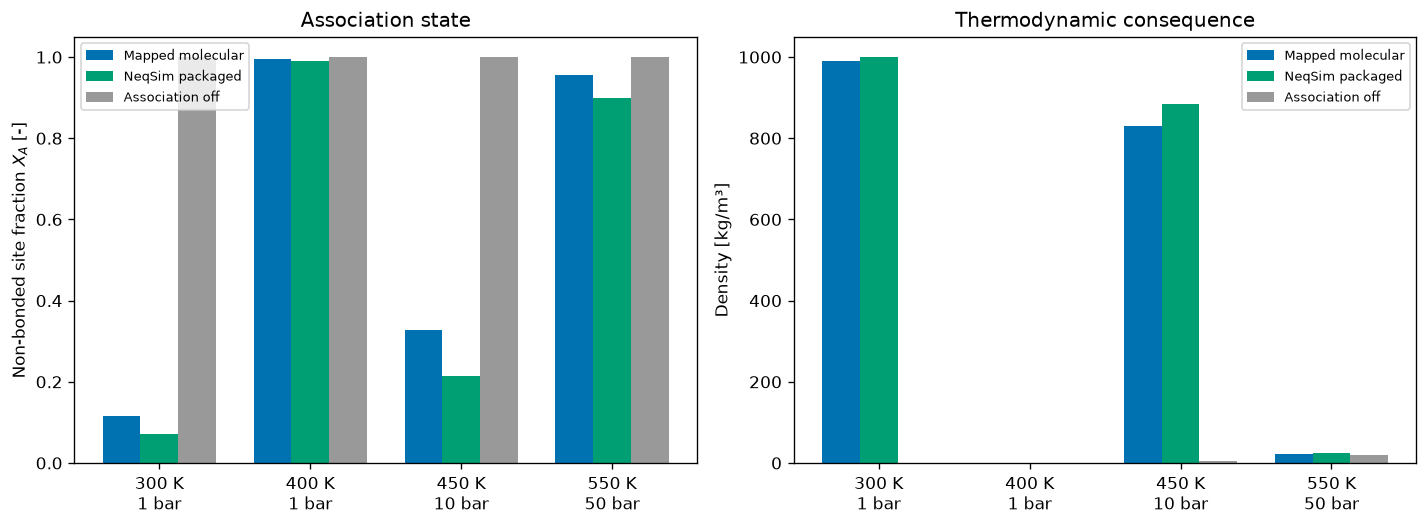

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))
x_positions = np.arange(len(state_points))
width = 0.25
colors = ["#0072B2", "#009E73", "#999999"]

for offset, (label, color) in enumerate(
    zip(parameter_sets, colors)
):
    selected = state_table[
        state_table["Parameter set"] == label
    ]
    positions = x_positions + (offset - 1) * width
    axes[0].bar(
        positions,
        selected["Mean X_A [-]"],
        width=width,
        color=color,
        label=label,
    )
    axes[1].bar(
        positions,
        selected["Density [kg/m3]"],
        width=width,
        color=color,
        label=label,
    )

state_labels = [
    f"{temperature:.0f} K\n{pressure:.0f} bar"
    for temperature, pressure in state_points
]
for axis in axes:
    axis.set_xticks(x_positions, state_labels)
    axis.legend(fontsize=8)
axes[0].set(
    ylabel="Non-bonded site fraction $X_A$ [-]",
    title="Association state",
    ylim=(0.0, 1.05),
)
axes[1].set(
    ylabel="Density [kg/m³]",
    title="Thermodynamic consequence",
)
plt.tight_layout()
plt.show()


## 13. Verify NeqSim's mass action and Helmholtz identity

The 300 K, 1 bar packaged-water state is checked two ways using values
read back from the live NeqSim phase:

1. solve the analytic pure-4C quadratic from NeqSim's
   $\Delta^{HB}$ and molar density;
2. reconstruct $F_{assoc}$ directly from all four site fractions.

These checks detect unit errors, missing `init(0)`, wrong site
multiplicity, and accidental use of generic rather than SAFT-VR
Mie-specific association setters.


In [16]:
identity_system = state_systems[
    (300.0, 1.0, "NeqSim packaged")
]
identity_phase = identity_system.getPhase(0)
identity_component = identity_phase.getComponent("water")
identity_x = np.array(
    [
        float(value)
        for value in identity_component.getXsiteAssoc()
    ]
)
neqsim_delta_m3mol = float(
    identity_phase.getDeltaAssoc(0, 2)
)
molar_density = (
    float(identity_phase.getDensity("kg/m3"))
    / WATER_MOLAR_MASS
)
density_delta = molar_density * neqsim_delta_m3mol
analytic_x = (
    -1.0 + math.sqrt(1.0 + 8.0 * density_delta)
) / (4.0 * density_delta)

reconstructed_f_assoc = float(
    np.sum(
        np.log(identity_x)
        - identity_x / 2.0
        + 0.5
    )
)
neqsim_f_assoc = float(
    identity_phase.F_ASSOC_SAFT()
)
identity_table = pd.Series(
    {
        "NeqSim mean X_A [-]": np.mean(identity_x),
        "analytic 4C X_A [-]": analytic_x,
        "absolute X_A difference [-]": abs(
            np.mean(identity_x) - analytic_x
        ),
        "NeqSim F_assoc [-]": neqsim_f_assoc,
        "reconstructed F_assoc [-]": (
            reconstructed_f_assoc
        ),
        "absolute F_assoc difference [-]": abs(
            neqsim_f_assoc - reconstructed_f_assoc
        ),
    },
    name="Analytical identity checks",
)
display(identity_table)


NeqSim mean X_A [-]                7.073250e-02
analytic 4C X_A [-]                7.073303e-02
absolute X_A difference [-]        5.295282e-07
NeqSim F_assoc [-]                -8.736866e+00
reconstructed F_assoc [-]         -8.736866e+00
absolute F_assoc difference [-]    0.000000e+00
Name: Analytical identity checks, dtype: float64

## 14. Sensitivity to energy and volume

A local grid around the mapped parameters verifies the expected
directions. Increasing either $\epsilon^{HB}$ or $K^{HB}$ lowers
$X_A$, meaning more bonded sites. The density response includes the
coupled EOS and phase-equilibrium solution.


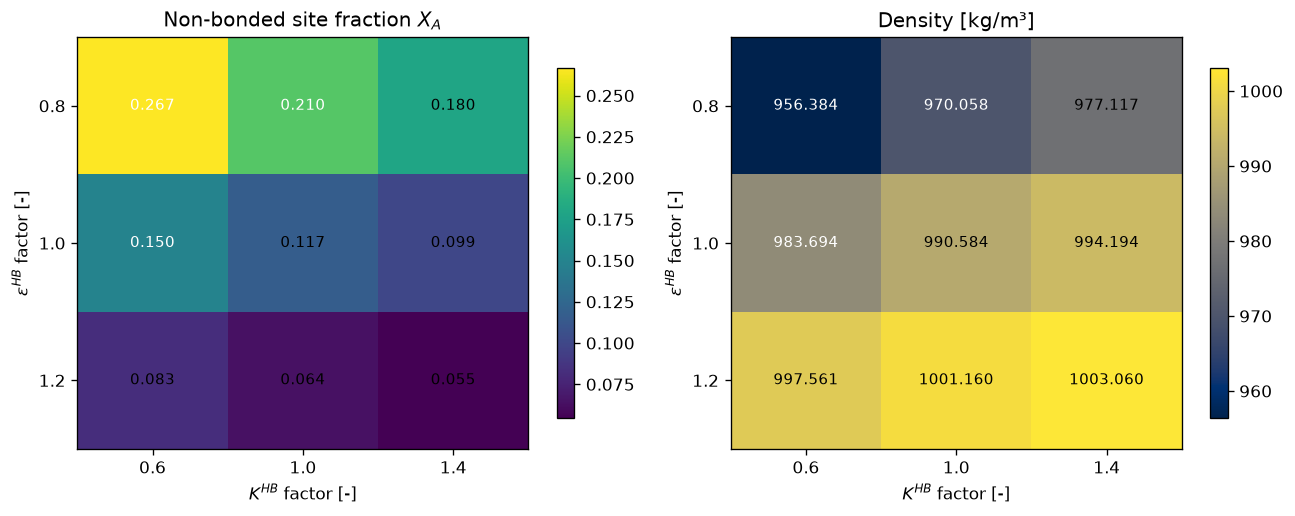

In [17]:
energy_factors = np.array([0.8, 1.0, 1.2])
volume_factors = np.array([0.6, 1.0, 1.4])
sensitivity_x = np.zeros(
    (len(energy_factors), len(volume_factors))
)
sensitivity_density = np.zeros_like(sensitivity_x)

for row_index, energy_factor in enumerate(energy_factors):
    for column_index, volume_factor in enumerate(
        volume_factors
    ):
        system = build_neqsim_water(
            300.0,
            1.0,
            mapped_epsilon_jmol * energy_factor,
            mapped_k_m3 * volume_factor,
        )
        phase = system.getPhase(0)
        component = phase.getComponent("water")
        sensitivity_x[row_index, column_index] = (
            np.mean(
                [
                    float(value)
                    for value
                    in component.getXsiteAssoc()
                ]
            )
        )
        sensitivity_density[
            row_index,
            column_index,
        ] = float(phase.getDensity("kg/m3"))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
for axis, values, title, color_map in [
    (
        axes[0],
        sensitivity_x,
        "Non-bonded site fraction $X_A$",
        "viridis",
    ),
    (
        axes[1],
        sensitivity_density,
        "Density [kg/m³]",
        "cividis",
    ),
]:
    image = axis.imshow(values, cmap=color_map, aspect="auto")
    axis.set_xticks(
        range(len(volume_factors)),
        [f"{value:.1f}" for value in volume_factors],
    )
    axis.set_yticks(
        range(len(energy_factors)),
        [f"{value:.1f}" for value in energy_factors],
    )
    axis.set(
        xlabel="$K^{HB}$ factor [-]",
        ylabel="$\\epsilon^{HB}$ factor [-]",
        title=title,
    )
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            axis.text(
                column_index,
                row_index,
                f"{values[row_index, column_index]:.3f}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if row_index + column_index < 2
                    else "black"
                ),
                fontsize=9,
            )
    fig.colorbar(image, ax=axis, shrink=0.85)
plt.tight_layout()
plt.show()


## 15. Engineering propagation: a NeqSim water heater

A native NeqSim `Stream` and `Heater` heat 1 mol/s of water from 300 K
to 450 K at 10 bar. The two association routes use the same nonpolar
SAFT-VR Mie parameters. Their duty difference is therefore the propagated
consequence of the association map, not a change in flow or boundary
conditions.


,Parameter set,Flow [mol/s],Inlet T [K],Outlet T [K],Pressure [bara],Duty [W]
0,Mapped molecular,1.0,300.0,450.0,10.0,4134.94762
1,NeqSim packaged,1.0,300.0,450.0,10.0,4026.59498


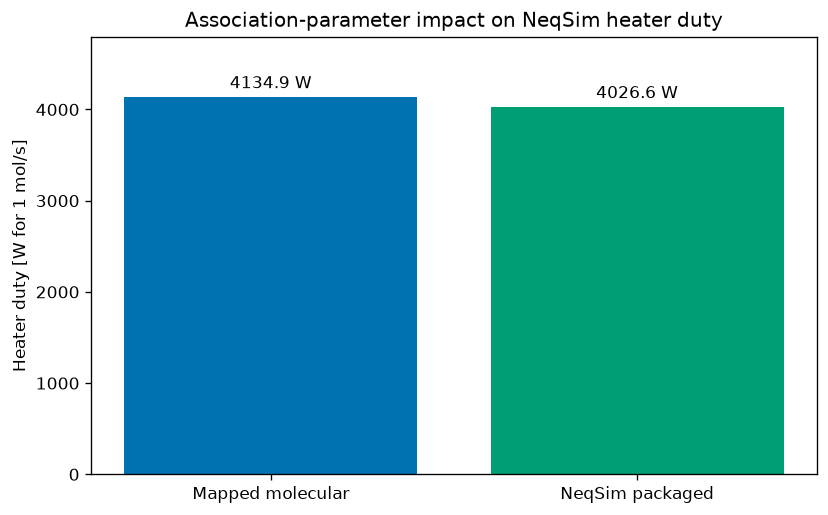

In [18]:
heater_rows = []
for label, epsilon_hb_jmol, k_hb_m3 in [
    (
        "Mapped molecular",
        mapped_epsilon_jmol,
        mapped_k_m3,
    ),
    (
        "NeqSim packaged",
        packaged_epsilon_jmol,
        packaged_k_m3,
    ),
]:
    fluid = build_neqsim_water(
        300.0,
        10.0,
        epsilon_hb_jmol,
        k_hb_m3,
    )
    stream = (
        jneqsim.process.equipment.stream.Stream(
            f"{label} feed",
            fluid,
        )
    )
    stream.setFlowRate(1.0, "mol/sec")
    stream.run()
    heater = (
        jneqsim.process.equipment.heatexchanger.Heater(
            f"{label} heater",
            stream,
        )
    )
    heater.setOutTemperature(450.0)
    heater.run()
    outlet = heater.getOutletStream()
    heater_rows.append(
        {
            "Parameter set": label,
            "Flow [mol/s]": 1.0,
            "Inlet T [K]": 300.0,
            "Outlet T [K]": float(
                outlet.getTemperature("K")
            ),
            "Pressure [bara]": float(
                outlet.getPressure("bara")
            ),
            "Duty [W]": float(heater.getDuty()),
        }
    )
heater_table = pd.DataFrame(heater_rows)
display(heater_table.round(5))

fig, axis = plt.subplots(figsize=(7.0, 4.4))
bars = axis.bar(
    heater_table["Parameter set"],
    heater_table["Duty [W]"],
    color=["#0072B2", "#009E73"],
)
axis.bar_label(bars, fmt="%.1f W", padding=3)
axis.set(
    ylabel="Heater duty [W for 1 mol/s]",
    title="Association-parameter impact on NeqSim heater duty",
)
axis.set_ylim(
    0.0,
    heater_table["Duty [W]"].max() * 1.16,
)
plt.tight_layout()
plt.show()


## 16. Reusable parameter record

The record includes the electronic-structure method, site scheme,
coarse-graining criterion, kernel normalization, units, and reference
state. These fields are part of the parameter definition; omitting them
makes a raw number unsafe to reuse.


In [19]:
parameter_record = {
    "component": "water",
    "association_scheme": "4C",
    "site_counts": {
        "donor_H": 2,
        "acceptor_e": 2,
    },
    "quantum_protocol": {
        "surface": "counterpoise MP2/aug-cc-pVDZ",
        "well_calibration": (
            "counterpoise CCSD(T)/aug-cc-pVDZ"
        ),
        "geometry": "fixed rOH=0.9572 A, HOH=104.52 deg",
    },
    "coarse_graining": {
        "retained_well_fraction": 0.60,
        "radial_bounds_angstrom": [
            mapping_geometry["r_low_angstrom"],
            mapping_geometry["r_high_angstrom"],
        ],
        "cone_half_angle_deg": (
            mapping_geometry["theta_cutoff_deg"]
        ),
        "bonding_volume_angstrom3": (
            mapping_geometry["bonding_volume_angstrom3"]
        ),
    },
    "neqsim_saft_vr_mie": {
        "epsilon_hb_jmol": mapped_epsilon_jmol,
        "k_hb_m3": mapped_k_m3,
        "kernel": "Dufal I from PhaseSAFTVRMie",
        "mapping_temperature_k": 298.15,
        "mapping_pressure_bar": 1.0e-6,
        "dilute_integral": dilute_integral,
    },
    "status": "teaching-quality; not bulk-property regressed",
}
print(json.dumps(parameter_record, indent=2))


{
  "component": "water",
  "association_scheme": "4C",
  "site_counts": {
    "donor_H": 2,
    "acceptor_e": 2
  },
  "quantum_protocol": {
    "surface": "counterpoise MP2/aug-cc-pVDZ",
    "well_calibration": "counterpoise CCSD(T)/aug-cc-pVDZ",
    "geometry": "fixed rOH=0.9572 A, HOH=104.52 deg"
  },
  "coarse_graining": {
    "retained_well_fraction": 0.6,
    "radial_bounds_angstrom": [
      2.71136557142447,
      3.810058381997875
    ],
    "cone_half_angle_deg": 35.80008188946573,
    "bonding_volume_angstrom3": 1.3224363385207107
  },
  "neqsim_saft_vr_mie": {
    "epsilon_hb_jmol": 15274.645370122593,
    "k_hb_m3": 5.939444785418405e-29,
    "kernel": "Dufal I from PhaseSAFTVRMie",
    "mapping_temperature_k": 298.15,
    "mapping_pressure_bar": 1e-06,
    "dilute_integral": 0.022265319172043645
  },
  "status": "teaching-quality; not bulk-property regressed"
}


## 17. Executable decision gates

These checks are intentionally redundant across scales. They verify
quantum-curve shape, mapped-parameter bounds, the published teqp value,
NeqSim's analytical identities, association trends, and the engineering
result.


In [20]:
mapped_state = state_table[
    (state_table["T [K]"] == 300.0)
    & (state_table["P [bar]"] == 1.0)
    & (
        state_table["Parameter set"]
        == "Mapped molecular"
    )
].iloc[0]
packaged_state = state_table[
    (state_table["T [K]"] == 300.0)
    & (state_table["P [bar]"] == 1.0)
    & (
        state_table["Parameter set"]
        == "NeqSim packaged"
    )
].iloc[0]
off_state = state_table[
    (state_table["T [K]"] == 300.0)
    & (state_table["P [bar]"] == 1.0)
    & (
        state_table["Parameter set"]
        == "Association off"
    )
].iloc[0]

checks = {
    "quantum scan has a repulsive wall": (
        radial_calibrated_k[0] > 0.0
    ),
    "quantum scan has an attractive well": (
        np.min(radial_calibrated_k) < -1000.0
    ),
    "CCSD(T) calibration is attractive": (
        calibration_ccsdt_k < 0.0
    ),
    "mapped epsilon is physically bounded": (
        5000.0 < mapped_epsilon_jmol < 30000.0
    ),
    "mapped NeqSim K is positive and finite": (
        np.isfinite(mapped_k_m3)
        and 1.0e-30 < mapped_k_m3 < 1.0e-27
    ),
    "teqp reproduces Dufal X_A": (
        abs(
            benchmark_x - expected_benchmark_x
        )
        < 1.0e-12
    ),
    "NeqSim 4C mass action closes": (
        abs(np.mean(identity_x) - analytic_x)
        < 1.0e-5
    ),
    "NeqSim association Helmholtz identity closes": (
        abs(
            neqsim_f_assoc - reconstructed_f_assoc
        )
        < 1.0e-8
    ),
    "association creates liquid-like 300 K water": (
        mapped_state["Density [kg/m3]"] > 900.0
        and packaged_state["Density [kg/m3]"] > 900.0
    ),
    "removing association destroys liquid-like state": (
        off_state["Density [kg/m3]"] < 10.0
    ),
    "stronger energy lowers X_A": bool(
        np.all(
            np.diff(sensitivity_x, axis=0) < 0.0
        )
    ),
    "larger volume lowers X_A": bool(
        np.all(
            np.diff(sensitivity_x, axis=1) < 0.0
        )
    ),
    "heater duties are finite and positive": bool(
        np.all(
            np.isfinite(heater_table["Duty [W]"])
            & (heater_table["Duty [W]"] > 0.0)
        )
    ),
}
check_table = pd.DataFrame(
    {
        "Check": list(checks),
        "Passed": list(checks.values()),
    }
)
display(check_table)
assert all(checks.values())
print(f"All {len(checks)} multiscale checks passed.")


All 13 multiscale checks passed.


,Check,Passed
0,quantum scan has a repulsive wall,True
1,quantum scan has an attractive well,True
2,CCSD(T) calibration is attractive,True
3,mapped epsilon is physically bounded,True
4,mapped NeqSim K is positive and finite,True
5,teqp reproduces Dufal X_A,True
6,NeqSim 4C mass action closes,True
7,NeqSim association Helmholtz identity closes,True
8,association creates liquid-like 300 K water,True
9,removing association destroys liquid-like state,True


## 18. Interpretation, limitations, and next components

**What this demonstrates**

- Site topology comes from molecular chemistry, not bulk PVT fitting.
- A counterpoise dimer surface supplies an energy scale and
  directionality.
- A stated radial/angular bonding convention supplies a reproducible
  association volume.
- NeqSim turns those parameters into bonded-site fractions, Helmholtz
  energy, phase behavior, density, enthalpy, and process duty.
- teqp provides an independent published Dufal association benchmark.

**What it does not establish**

- MP2/CCSD(T)/aug-cc-pVDZ at a frozen dimer geometry is not a
  CCSD(T)/CBS many-body water potential.
- The 60% bonding criterion is not unique. The sensitivity plot is part
  of the result.
- Agreement in order of magnitude with the packaged NeqSim parameters
  is not a bulk-property validation.
- Raw $K^{HB}$ values from different Dufal kernels are not automatically
  interchangeable.
- TPT1 neglects association cooperativity, rings, double bonding, and
  site blocking unless extended.

**Extension sequence**

1. **Methanol or ethanol (2B/3B):** repeat the alcohol dimer radial and
   angular map, then validate vapor pressure, liquid density, and heat
   of vaporization.
2. **Ammonia:** map three donor directions and one acceptor direction,
   then test alternative site schemes.
3. **Water + hydrocarbon:** calculate unlike water-solute surfaces and
   validate water solubility and mutual phase equilibrium.
4. **Water + alcohol or glycol:** include cross association explicitly;
   pure-component parameters alone do not determine unlike-site
   strengths.
5. **Production model:** use relaxed geometries, CCSD(T)/CBS or a
   validated many-body potential, configurational integration over
   translations and rotations, uncertainty propagation, and
   liquid/mixture benchmarks.


## 19. References

1. S. Dufal, T. Lafitte, A. J. Haslam, A. Galindo, G. N. I. Clark,
   C. Vega, and G. Jackson, [The A in SAFT: developing the contribution
   of association to the Helmholtz free energy within a Wertheim TPT1
   treatment of generic Mie fluids](https://doi.org/10.1080/00268976.2015.1029027),
   *Molecular Physics* **113** (2015) 948-984.
2. [teqp association model documentation](https://teqp.readthedocs.io/en/latest/models/Association.html)
   and its open-source Dufal-water verification example.
3. [NeqSim `PhaseSAFTVRMie` source](https://github.com/equinor/neqsim/blob/207a82cb51a83377e1383e8be7542fa6adf1bac7/src/main/java/neqsim/thermo/phase/PhaseSAFTVRMie.java),
   including the Dufal association integral, site mass action, and
   Helmholtz contribution used here.
4. Q. Sun *et al.*, [Recent developments in the PySCF program
   package](https://doi.org/10.1063/5.0006074), *J. Chem. Phys.*
   **153** (2020) 024109.
5. S. F. Boys and F. Bernardi,
   [The calculation of small molecular interactions by the differences
   of separate total energies](https://doi.org/10.1080/00268977000101561),
   *Molecular Physics* **19** (1970) 553-566.

The exact NeqSim, teqp, PySCF, Python, and Java versions used for the
retained outputs are printed near the top of the notebook.
